## Grupo 2 Proyecto Modelado Predictivo




## Idea general del pipeline

El entrenamiento completo sigue este orden:

1. **Leer los datos** de partidos.
2. **Verificar** que cada partido tenga exactamente dos filas (una por equipo).
3. **Crear columnas del rival** para que cada fila conozca a su oponente.
4. **Calcular Elo pre-partido** para cada equipo.
5. **Unir las dos filas del partido** y crear una sola fila por encuentro.
6. **Separar train y test en orden temporal**.
7. **Ajustar Dixon-Coles + Elo** sobre los partidos históricos.

Posterior vamos a  **Crear modelo base para comparar**, **Convertir los goles esperados en una matriz de marcadores**, **Obtener probabilidades** de home/draw/away y **Evaluar** 



## Importar librerías y definir constantes necesarias



In [2]:
# Librerías principales
import math
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any, Dict, Optional, Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize, minimize_scalar
from scipy.stats import poisson
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

# Constantes útiles
EPS = 1e-12
OUTCOME_ORDER = ["home", "draw", "away"]
OUTCOME_TO_INDEX = {name: idx for idx, name in enumerate(OUTCOME_ORDER)}

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

## 1) Cómo deben venir los datos

La estructura mínima esperada es una tabla con **una fila por equipo en cada partido**.

Eso significa que cada encuentro aparece dos veces:

- una fila para el equipo local,
- una fila para el equipo visitante.

Las columnas mínimas necesarias son:

- `event_id`: identificador del partido
- `start_time`: fecha/hora
- `team_id`: identificador del equipo
- `team_name`: nombre del equipo
- `is_home`: 1 si juega en casa, 0 si no
- `score`: goles marcados por ese equipo

### ¿Por qué usamos este formato inicialmente?
En los trabajos de las asignaturas anteriores, este fue el formato que definimos para el dataset de partidos, y nos resultó cómodo para trabajar con los datos.Es por eso que tenemos ya un dataset con esta estructura, el cual se encuentra en la carpeta ./dataset/team_statistics_clean.parquet. Este es el dataset que usaremos para este trabajo.  Después, más adelante, transformaremos ese formato a **una fila por partido** que es lo que necesita el modelo.

In [3]:
#Cargamos el dataset y lo visualizamos

df = pd.read_parquet('./dataset/team_statistics_clean.parquet')
team_df_raw = df[['event_id', 'start_time', 'team_id', 'team_name', 'is_home', 'score']]
team_df_raw["start_time"] = pd.to_datetime(team_df_raw["start_time"], utc=True)

/tmp/ipykernel_556488/4117508292.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  team_df_raw["start_time"] = pd.to_datetime(team_df_raw["start_time"], utc=True)


## El dataframe original luce asi:

In [4]:
df.head(8)

,ball_possession,chances_created,start_time,clearances,corner_kicks,crosses_successful,crosses_total,defensive_blocks,dribbles_completed,fouls,free_kicks,goal_kicks,interceptions,long_passes_successful,long_passes_total,long_passes_unsuccessful,loss_of_possession,offsides,passes_successful,passes_total,passes_unsuccessful,shots_blocked,shots_off_target,shots_on_target,shots_total,tackles_successful,tackles_total,throw_ins,event_id,team_id,team_name,is_home,score,shot_accuracy,shot_volume_per_possession
0,45.0,7.0,2025-04-12T14:15:00+00:00,28.0,3,1.0,12.0,3.0,2.0,10,18,10,0.0,6.0,31.0,25.0,19.0,1,176.0,201.0,25.0,2,4,3,9,5.0,5.0,25,sr:sport_event:50852687,sr:competitor:2859,Getafe CF,1,1,0.333333,0.200000
1,55.0,5.0,2025-04-12T14:15:00+00:00,41.0,2,2.0,13.0,6.0,0.0,16,11,9,1.0,17.0,39.0,22.0,17.0,2,267.0,297.0,30.0,1,3,4,8,3.0,4.0,23,sr:sport_event:50852687,sr:competitor:6577,UD Las Palmas,0,3,0.500000,0.145455
2,56.0,9.0,2023-10-29T20:00:00+00:00,34.0,4,3.0,11.0,21.0,30.0,8,10,6,36.0,36.0,59.0,23.0,76.0,5,636.0,712.0,76.0,1,3,5,9,44.0,75.0,14,sr:sport_event:41893117,sr:competitor:2836,Atletico Madrid,1,2,0.555556,0.160714
3,44.0,4.0,2023-10-29T20:00:00+00:00,29.0,4,4.0,22.0,8.0,13.0,9,13,9,35.0,21.0,42.0,21.0,78.0,1,307.0,383.0,76.0,1,3,1,5,31.0,75.0,14,sr:sport_event:41893117,sr:competitor:2885,Deportivo Alaves,0,1,0.200000,0.113636
4,41.0,9.0,2023-09-18T19:00:00+00:00,10.0,4,5.0,18.0,12.0,15.0,12,23,2,20.0,32.0,46.0,14.0,71.0,3,234.0,298.0,64.0,0,5,7,12,73.0,121.0,25,sr:sport_event:41892991,sr:competitor:33779,Granada CF,1,2,0.583333,0.292683
5,59.0,8.0,2023-09-18T19:00:00+00:00,29.0,5,1.0,7.0,13.0,31.0,19,15,7,34.0,23.0,37.0,14.0,72.0,4,380.0,433.0,53.0,5,2,7,14,48.0,121.0,22,sr:sport_event:41892991,sr:competitor:24264,Girona FC,0,4,0.500000,0.237288
6,67.0,8.0,2025-03-09T17:30:00+00:00,21.0,11,6.0,23.0,1.0,2.0,11,14,6,2.0,17.0,23.0,6.0,31.0,2,481.0,525.0,44.0,3,2,5,10,9.0,9.0,20,sr:sport_event:50852605,sr:competitor:2816,Real Betis Seville,1,1,0.500000,0.149254
7,33.0,7.0,2025-03-09T17:30:00+00:00,35.0,1,5.0,12.0,9.0,0.0,13,13,9,8.0,10.0,37.0,27.0,30.0,1,197.0,223.0,26.0,1,5,2,8,15.0,18.0,10,sr:sport_event:50852605,sr:competitor:6577,UD Las Palmas,0,0,0.250000,0.242424


## Este otro dataframe creado tiene solamente las columnas que usaremos para el modelo

In [5]:
team_df_raw.head(8)

,event_id,start_time,team_id,team_name,is_home,score
0,sr:sport_event:50852687,2025-04-12 14:15:00+00:00,sr:competitor:2859,Getafe CF,1,1
1,sr:sport_event:50852687,2025-04-12 14:15:00+00:00,sr:competitor:6577,UD Las Palmas,0,3
2,sr:sport_event:41893117,2023-10-29 20:00:00+00:00,sr:competitor:2836,Atletico Madrid,1,2
3,sr:sport_event:41893117,2023-10-29 20:00:00+00:00,sr:competitor:2885,Deportivo Alaves,0,1
4,sr:sport_event:41892991,2023-09-18 19:00:00+00:00,sr:competitor:33779,Granada CF,1,2
5,sr:sport_event:41892991,2023-09-18 19:00:00+00:00,sr:competitor:24264,Girona FC,0,4
6,sr:sport_event:50852605,2025-03-09 17:30:00+00:00,sr:competitor:2816,Real Betis Seville,1,1
7,sr:sport_event:50852605,2025-03-09 17:30:00+00:00,sr:competitor:6577,UD Las Palmas,0,0


## 2) Utilidades básicas

Estas funciones utilitarias ayudan a:

- asegurar que las fechas estén bien parseadas,
- medir error de goles,
- medir calidad de probabilidades,
- convertir resultados a formatos más cómodos.

Son funciones auxiliares y sencillas que nos ayudaran mas adelante en el notebook.

In [6]:
DEFAULT_REQUIRED_COLUMNS = [
    "event_id",
    "start_time",
    "team_id",
    "team_name",
    "is_home",
    "score",
]

def _ensure_datetime(df: pd.DataFrame, col: str) -> pd.DataFrame:
    # Convierte una columna a datetime.
    # Si alguna fecha no se puede convertir, falla para evitar errores silenciosos.
    out = df.copy()
    out[col] = pd.to_datetime(out[col], utc=True, errors="coerce")
    if out[col].isna().any():
        raise ValueError(f"La columna '{col}' contiene fechas inválidas.")
    #Retornamos la final dataframe con la columna convertida a datetime    
    return out


def evaluate_predictions(y_true: Sequence[float], y_pred: Sequence[float]) -> Dict[str, float]:
    # Métricas básicas de regresión para comparar goles reales vs goles esperados.
    #Aqui es imporatnte usar np.asarray para convertir las secuencias en arrays lo que optimiza el calculo de las metricas ya que podemos 
    #hacer calculos con vectores y no con bucles, y usando funciones vectorizadas de numpy y scikit-learn.
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "r2": float(r2_score(y_true, y_pred)),
        "mean_true": float(y_true.mean()),
        "mean_pred": float(y_pred.mean()),
    }


def average_goal_mae(
    y_home_true: Sequence[float], 
    y_home_pred: Sequence[float],
    y_away_true: Sequence[float],
    y_away_pred: Sequence[float],
) -> float:
    # Promedia el MAE de goles locales y visitantes.
    return float(
        (
            mean_absolute_error(np.asarray(y_home_true, dtype=float), np.asarray(y_home_pred, dtype=float))
            + mean_absolute_error(np.asarray(y_away_true, dtype=float), np.asarray(y_away_pred, dtype=float))
        ) / 2.0
    )


def probs_to_array(prob_home: float, prob_draw: float, prob_away: float) -> np.ndarray:
    # Garantiza que las probabilidades sean positivas y sumen 1.
    arr = np.asarray([prob_home, prob_draw, prob_away], dtype=float)
    arr = np.clip(arr, EPS, None)
    arr /= arr.sum()
    return arr


def predicted_outcome(prob_home: float, prob_draw: float, prob_away: float) -> str:
    # Devuelve la clase con mayor probabilidad: home, draw o away.
    arr = probs_to_array(prob_home, prob_draw, prob_away)
    return OUTCOME_ORDER[int(np.argmax(arr))]


def safe_log_loss(prob_actual: float) -> float:
    # Evita log(0)
    return float(-math.log(float(np.clip(prob_actual, EPS, 1.0))))


def multiclass_brier(prob_home: float, prob_draw: float, prob_away: float, actual_outcome: str) -> float:
    # Brier score multicategoría. Esta funcion da un número entre 0 y 1 que indica cuánta distancia hubo entre los porcentajes y lo que pasó.
    y = np.array([0.0, 0.0, 0.0], dtype=float)
    y[OUTCOME_TO_INDEX[actual_outcome]] = 1.0
    p = probs_to_array(prob_home, prob_draw, prob_away)
    return float(np.mean((p - y) ** 2))


def ranked_probability_score(prob_home: float, prob_draw: float, prob_away: float, actual_outcome: str) -> float:
    # RPS: útil cuando hay orden natural entre home-draw-away. El RPS (Ranked Probability Score) es la métrica más "justa" para el fútbol, 
    # porque entiende que los resultados tienen un orden
    y = np.array([0.0, 0.0, 0.0], dtype=float)
    y[OUTCOME_TO_INDEX[actual_outcome]] = 1.0
    p = probs_to_array(prob_home, prob_draw, prob_away)
    cdf_p = np.cumsum(p)
    cdf_y = np.cumsum(y)
    return float(np.mean((cdf_p[:-1] - cdf_y[:-1]) ** 2))

## 3) Preparación de datos

Aquí ocurre una parte muy importante del flujo.

### 3.1 Verificar que cada partido tenga dos filas
Si un `event_id` no tiene exactamente dos filas, ese partido está incompleto o mal formado.

### 3.2 Crear columnas del oponente
Cada fila representa a un equipo. Pero para modelar fútbol necesitamos saber también:
- quién era el rival,
- cuántos goles recibió,
- si ganó, empató o perdió.

### 3.3 Construir dataset a nivel partido
Después transformamos las dos filas de cada partido en una sola fila con:
- equipo local,
- equipo visitante,
- goles local,
- goles visitante,
- elo local,
- elo visitante,
- diferencia de elo.

In [7]:
def validate_two_rows_per_match(df: pd.DataFrame) -> pd.DataFrame:
    # Solo nos quedamos con partidos que tengan exactamente 2 filas.
    counts = df.groupby("event_id").size()
    valid_ids = counts[counts == 2].index

    cleaned = df[df["event_id"].isin(valid_ids)].copy()
    cleaned = cleaned.sort_values(["start_time", "event_id", "is_home", "team_id"]).reset_index(drop=True)

    if cleaned.empty:
        raise ValueError("No quedan partidos válidos tras filtrar event_id con exactamente 2 filas.")

    invalid_count = int((counts != 2).sum())
    if invalid_count > 0:
        print(f"[INFO] Se eliminaron {invalid_count} partidos inválidos.")
    return cleaned


def add_opponent_columns(df: pd.DataFrame) -> pd.DataFrame:
    # Creamos una copia renombrada para hacer un self-merge por event_id.
    # Así cada fila del equipo puede encontrar a su oponente.
    base_cols = ["event_id", "team_id", "team_name", "is_home", "score"]
    opp = df[base_cols].rename(
        columns={
            "team_id": "opponent_team_id",
            "team_name": "opponent_team_name",
            "is_home": "opponent_is_home",
            "score": "goals_conceded",
        }
    )

    merged = df.merge(opp, on="event_id", how="left")

    # Eliminamos la unión de la fila consigo misma.
    merged = merged[merged["team_id"] != merged["opponent_team_id"]].copy()

    # Puntos del partido desde la perspectiva de ese equipo.
    merged["match_result_points"] = np.where(
        merged["score"] > merged["goals_conceded"],
        3,
        np.where(merged["score"] == merged["goals_conceded"], 1, 0),
    )

    merged["goal_difference"] = merged["score"] - merged["goals_conceded"]
    return merged.reset_index(drop=True)


def build_match_level_dataset(team_df: pd.DataFrame) -> pd.DataFrame:
    # Partimos el dataset en local y visitante.
    data = team_df.copy().sort_values(["start_time", "event_id", "is_home"]).reset_index(drop=True)

    home = data[data["is_home"] == 1].copy()
    away = data[data["is_home"] == 0].copy()

    # Renombramos columnas para que el merge sea claro.
    home = home.rename(
        columns={
            "team_id": "home_team_id",
            "team_name": "home_team_name",
            "score": "home_goals",
            "elo_pre_match": "home_elo_pre_match",
        }
    )

    away = away.rename(
        columns={
            "team_id": "away_team_id",
            "team_name": "away_team_name",
            "score": "away_goals",
            "elo_pre_match": "away_elo_pre_match",
        }
    )

    # Unimos local y visitante en una sola fila por partido.
    matches = home[["event_id", "start_time", "home_team_id", "home_team_name", "home_goals", "home_elo_pre_match"]].merge(
        away[["event_id", "away_team_id", "away_team_name", "away_goals", "away_elo_pre_match"]],
        on="event_id",
        how="inner",
    )

    # Variables útiles para entrenamiento y evaluación.
    matches["elo_diff"] = matches["home_elo_pre_match"] - matches["away_elo_pre_match"]
    matches["total_goals"] = matches["home_goals"] + matches["away_goals"]
    matches["home_win"] = (matches["home_goals"] > matches["away_goals"]).astype(int)
    matches["draw"] = (matches["home_goals"] == matches["away_goals"]).astype(int)
    matches["away_win"] = (matches["home_goals"] < matches["away_goals"]).astype(int)

    return matches.sort_values(["start_time", "event_id"]).reset_index(drop=True)

In [8]:
team_df_clean = validate_two_rows_per_match(team_df_raw)
team_df_with_opp = add_opponent_columns(team_df_clean)

print("Vista team-level con columnas del rival:")
display(team_df_with_opp.head(6))

Vista team-level con columnas del rival:


,event_id,start_time,team_id,team_name,is_home,score,opponent_team_id,opponent_team_name,opponent_is_home,goals_conceded,match_result_points,goal_difference
0,sr:sport_event:41892223,2023-08-11 17:30:00+00:00,sr:competitor:2818,Rayo Vallecano,0,2,sr:competitor:2858,UD Almeria,1,0,3,2
1,sr:sport_event:41892223,2023-08-11 17:30:00+00:00,sr:competitor:2858,UD Almeria,1,0,sr:competitor:2818,Rayo Vallecano,0,2,0,-2
2,sr:sport_event:41892235,2023-08-11 20:00:00+00:00,sr:competitor:2828,Valencia CF,0,2,sr:competitor:2833,Sevilla FC,1,1,3,1
3,sr:sport_event:41892235,2023-08-11 20:00:00+00:00,sr:competitor:2833,Sevilla FC,1,1,sr:competitor:2828,Valencia CF,0,2,0,-1
4,sr:sport_event:41892337,2023-08-12 15:00:00+00:00,sr:competitor:24264,Girona FC,0,1,sr:competitor:2824,Real Sociedad San Sebastian,1,1,1,0
5,sr:sport_event:41892337,2023-08-12 15:00:00+00:00,sr:competitor:2824,Real Sociedad San Sebastian,1,1,sr:competitor:24264,Girona FC,0,1,1,0


### Qué se logró hasta aquí

Ya tenemos una tabla donde cada fila "entiende" el partido desde la perspectiva de un equipo:

- goles a favor,
- goles en contra,
- rival,
- puntos obtenidos,
- diferencia de goles.

Eso es útil para construir rating Elo y para inspecciones intermedias.

## 4) Elo pre-partido

Antes de entrar al modelo, este pipeline calcula un **Elo antes de cada partido**.

### Intuición de Elo
Elo es una forma sencilla de resumir la fortaleza reciente de un equipo.

- Si un equipo gana a rivales fuertes, sube.
- Si pierde contra rivales débiles, baja.
- Si empata, el cambio depende de lo esperado.

### Fórmula base del resultado esperado

Si el equipo A tiene rating \(R_A\) y el equipo B tiene \(R_B\), la probabilidad esperada de A es:

\[
E_A = \frac{1}{1 + 10^{(R_B - R_A)/400}}
\]

Luego se actualiza con:

\[
R_A^{nuevo} = R_A + K (S_A - E_A)
\]

donde:

- \(S_A\) es el resultado real: 1 si gana, 0.5 si empata, 0 si pierde,
- \(E_A\) es lo esperado,
- \(K\) controla cuánto cambia el rating.

### Qué añade esta implementación

Esta versión añade tres detalles prácticos:

1. **Ventaja de localía en puntos Elo**  
   Al calcular la expectativa, el local recibe un pequeño extra.

2. **K dinámico**  
   Al inicio de la vida de un equipo, Elo cambia más rápido. Luego se estabiliza.

3. **Multiplicador por diferencia de goles**  
   Ganar por más margen mueve un poco más el rating.

In [9]:
@dataclass
class EloConfig:
    initial_rating: float = 1500.0
    k_initial: float = 150.0
    k_floor: float = 20.0
    k_decay_rate: float = 0.03
    home_advantage_points: float = 70.0


def compute_pre_match_elo(df: pd.DataFrame, cfg: EloConfig) -> tuple[pd.DataFrame, Dict[str, float]]:
    # Ordenamos por fecha para que el rating se calcule en orden cronológico.
    data = df.copy().sort_values(["start_time", "event_id", "is_home", "team_id"]).reset_index(drop=True)

    current_ratings: Dict[str, float] = {}
    matches_played: Dict[str, int] = {}
    pre_match_elo = pd.Series(index=data.index, dtype=float)

    def get_k_factor(n_matches: int) -> float:
        # Al principio K es alto; luego va decayendo hacia un piso.
        return cfg.k_floor + (cfg.k_initial - cfg.k_floor) * math.exp(-cfg.k_decay_rate * n_matches)

    def expected_score(rating_a: float, rating_b: float) -> float:
        return 1.0 / (1.0 + 10.0 ** ((rating_b - rating_a) / 400.0))

    def mov_multiplier(goal_diff: int) -> float:
        # Un margen mayor aumenta ligeramente la actualización.
        return max(1.0, math.log1p(abs(goal_diff)))

    match_events = data[["event_id", "start_time"]].drop_duplicates("event_id").sort_values(["start_time", "event_id"])
    index_by_event = data.groupby("event_id").indices

    for _, match_meta in match_events.iterrows():
        event_id = match_meta["event_id"]
        idx = list(index_by_event[event_id])

        if len(idx) != 2:
            continue

        row_a = data.loc[idx[0]]
        row_b = data.loc[idx[1]]

        team_a = str(row_a["team_id"])
        team_b = str(row_b["team_id"])

        # Si el equipo no existe aún, empieza en el rating inicial.
        current_ratings.setdefault(team_a, cfg.initial_rating)
        current_ratings.setdefault(team_b, cfg.initial_rating)
        matches_played.setdefault(team_a, 0)
        matches_played.setdefault(team_b, 0)

        rating_a = current_ratings[team_a]
        rating_b = current_ratings[team_b]

        # Sumamos ventaja de local al calcular expectativa, no al guardar el rating puro.
        is_home_a = bool(row_a["is_home"])
        rating_a_for_expectation = rating_a + (cfg.home_advantage_points if is_home_a else 0.0)
        rating_b_for_expectation = rating_b + (cfg.home_advantage_points if not is_home_a else 0.0)

        # Guardamos el Elo justo antes del partido.
        pre_match_elo.loc[idx[0]] = rating_a
        pre_match_elo.loc[idx[1]] = rating_b

        exp_a = expected_score(rating_a_for_expectation, rating_b_for_expectation)
        exp_b = 1.0 - exp_a

        score_a = int(row_a["score"])
        score_b = int(row_b["score"])

        if score_a > score_b:
            actual_a, actual_b = 1.0, 0.0
        elif score_a < score_b:
            actual_a, actual_b = 0.0, 1.0
        else:
            actual_a, actual_b = 0.5, 0.5

        multiplier = mov_multiplier(abs(score_a - score_b))
        k_a = get_k_factor(matches_played[team_a])
        k_b = get_k_factor(matches_played[team_b])

        # Actualización Elo.
        current_ratings[team_a] += k_a * multiplier * (actual_a - exp_a)
        current_ratings[team_b] += k_b * multiplier * (actual_b - exp_b)

        matches_played[team_a] += 1
        matches_played[team_b] += 1

    data["elo_pre_match"] = pre_match_elo.astype(float)
    return data, current_ratings.copy()

In [10]:
elo_cfg = EloConfig()
team_df_elo, final_ratings = compute_pre_match_elo(team_df_with_opp, elo_cfg)

id_to_name = team_df_elo.set_index('team_id')['team_name'].to_dict()

print("Ratings finales:")
display(pd.DataFrame(
    [
        {
            "team_id": k, 
            "team_name": id_to_name.get(k, "Desconocido"), 
            "final_elo": v
        } 
        for k, v in final_ratings.items()
    ]
).sort_values("final_elo", ascending=False))

Ratings finales:


,team_id,team_name,final_elo
14,sr:competitor:2817,FC Barcelona,1826.560149
8,sr:competitor:2829,Real Madrid,1803.289258
19,sr:competitor:2836,Atletico Madrid,1709.153199
13,sr:competitor:2819,Villarreal CF,1693.488400
12,sr:competitor:2816,Real Betis Seville,1591.595688
11,sr:competitor:2821,RC Celta de Vigo,1577.053176
21,sr:competitor:2814,Espanyol Barcelona,1538.061970
9,sr:competitor:2825,Athletic Bilbao,1526.698154
5,sr:competitor:2824,Real Sociedad San Sebastian,1502.936355
10,sr:competitor:2820,CA Osasuna,1502.402204


### Interpretación

La columna `elo_pre_match` es importante porque representa la **información disponible antes de que ocurra el partido**.

Eso es correcto desde el punto de vista metodológico:  
el modelo nunca debe usar información futura para predecir el pasado.

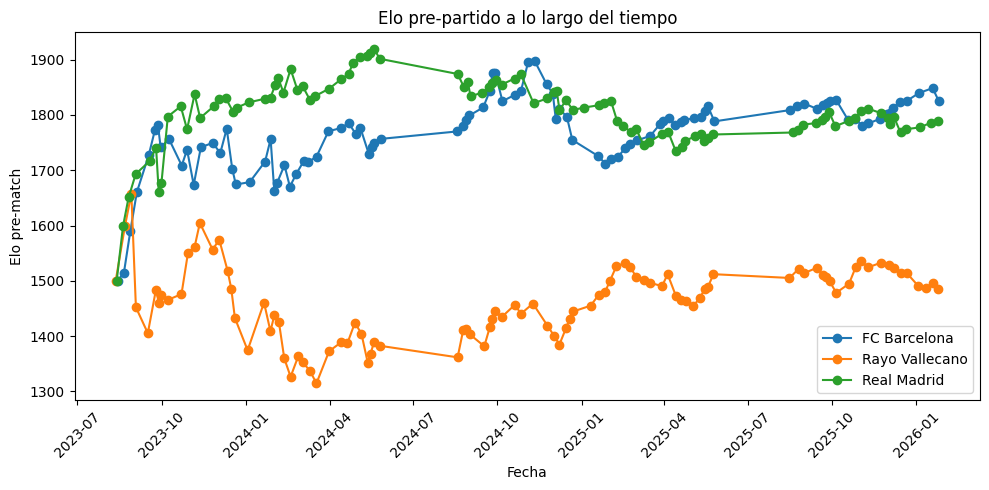

In [11]:
# Visualizamos cómo cambia el Elo de cada equipo partido a partido para algunos equipos

elo_plot_df = team_df_elo.sort_values(["start_time", "event_id"]).copy()
teams = ["Real Madrid", "FC Barcelona", "Rayo Vallecano"]
elo_md_barc_rayo = elo_plot_df[
    elo_plot_df["team_name"].isin(["Real Madrid", "FC Barcelona", "Rayo Vallecano"])
]

plt.figure(figsize=(10, 5))
for team_name, grp in elo_md_barc_rayo.groupby("team_name"):
    g = grp.sort_values("start_time")
    plt.plot(g["start_time"], g["elo_pre_match"], marker="o", label=team_name)

plt.title("Elo pre-partido a lo largo del tiempo")
plt.xlabel("Fecha")
plt.ylabel("Elo pre-match")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5) Dataset a nivel partido

Una vez calculado Elo en cada fila de equipo, construimos el dataset final de entrenamiento:

- una fila por partido,
- identificador del local y visitante,
- goles local y visitante,
- Elo local y visitante,
- diferencia de Elo.

Ese es el formato que usa el modelo.

In [12]:
matches = build_match_level_dataset(team_df_elo)
matches.head()

,event_id,start_time,home_team_id,home_team_name,home_goals,home_elo_pre_match,away_team_id,away_team_name,away_goals,away_elo_pre_match,elo_diff,total_goals,home_win,draw,away_win
0,sr:sport_event:41892223,2023-08-11 17:30:00+00:00,sr:competitor:2858,UD Almeria,0,1500.0,sr:competitor:2818,Rayo Vallecano,2,1500.0,0.0,2,0,0,1
1,sr:sport_event:41892235,2023-08-11 20:00:00+00:00,sr:competitor:2833,Sevilla FC,1,1500.0,sr:competitor:2828,Valencia CF,2,1500.0,0.0,3,0,0,1
2,sr:sport_event:41892337,2023-08-12 15:00:00+00:00,sr:competitor:2824,Real Sociedad San Sebastian,1,1500.0,sr:competitor:24264,Girona FC,1,1500.0,0.0,2,0,1,0
3,sr:sport_event:41892237,2023-08-12 17:30:00+00:00,sr:competitor:6577,UD Las Palmas,1,1500.0,sr:competitor:2826,RCD Mallorca,1,1500.0,0.0,2,0,1,0
4,sr:sport_event:41892225,2023-08-12 19:30:00+00:00,sr:competitor:2825,Athletic Bilbao,0,1500.0,sr:competitor:2829,Real Madrid,2,1500.0,0.0,2,0,0,1


## 6) División temporal: development y test

En series temporales deportivas, **no conviene mezclar partidos viejos y nuevos al azar**.

Lo correcto es respetar el tiempo:

- partidos antiguos para entrenar,
- partidos más recientes para probar.

Eso evita **data leakage**.

### Regla de oro en este notebook
Usaremos una separación sencilla:
- primeras observaciones -> `dev`
- últimas observaciones -> `test`

In [13]:
def temporal_dev_test_split(matches: pd.DataFrame, test_ratio: float = 0.20) -> tuple[pd.DataFrame, pd.DataFrame]:
    if not 0 < test_ratio < 1:
        raise ValueError("test_ratio debe estar entre 0 y 1.")

    data = matches.sort_values("start_time").reset_index(drop=True)
    n = len(data)
    test_size = max(1, int(round(n * test_ratio)))

    if test_size >= n:
        raise ValueError("No hay suficientes filas para hacer split temporal.")

    dev = data.iloc[: n - test_size].copy()
    test = data.iloc[n - test_size :].copy()
    return dev, test

dev_df, test_df = temporal_dev_test_split(matches, test_ratio=0.20)

print("Partidos en development:", len(dev_df))
print("Partidos en test:", len(test_df))

display(dev_df.tail(3))
display(test_df.head(3))

Partidos en development: 775
Partidos en test: 194


,event_id,start_time,home_team_id,home_team_name,home_goals,home_elo_pre_match,away_team_id,away_team_name,away_goals,away_elo_pre_match,elo_diff,total_goals,home_win,draw,away_win
772,sr:sport_event:61623960,2025-08-23 17:30:00+00:00,sr:competitor:2836,Atletico Madrid,1,1653.297790,sr:competitor:2846,Elche CF,1,1503.445373,149.852417,2,0,1,0
773,sr:sport_event:61623968,2025-08-23 19:30:00+00:00,sr:competitor:2849,Levante UD,2,1434.330579,sr:competitor:2817,FC Barcelona,3,1815.959859,-381.629280,5,0,0,1
774,sr:sport_event:61623962,2025-08-24 15:00:00+00:00,sr:competitor:2820,CA Osasuna,1,1531.734887,sr:competitor:2828,Valencia CF,0,1510.016837,21.718050,1,1,0,0


,event_id,start_time,home_team_id,home_team_name,home_goals,home_elo_pre_match,away_team_id,away_team_name,away_goals,away_elo_pre_match,elo_diff,total_goals,home_win,draw,away_win
775,sr:sport_event:61623972,2025-08-24 17:30:00+00:00,sr:competitor:2824,Real Sociedad San Sebastian,2,1451.545381,sr:competitor:2814,Espanyol Barcelona,2,1522.244151,-70.698771,4,0,1,0
776,sr:sport_event:61623976,2025-08-24 17:30:00+00:00,sr:competitor:2819,Villarreal CF,5,1679.684072,sr:competitor:24264,Girona FC,0,1383.021998,296.662073,5,1,0,0
777,sr:sport_event:61623964,2025-08-24 19:30:00+00:00,sr:competitor:2851,Real Oviedo,0,1467.283455,sr:competitor:2829,Real Madrid,3,1773.298484,-306.015029,3,0,0,1


## 7) Base teórica del modelo Dixon-Coles

Ahora llegamos al núcleo del notebook.

---

### 7.1 Modelo Poisson para goles

Un supuesto clásico en fútbol es que los goles de cada equipo siguen una distribución de Poisson:

\[
P(X = x) = \frac{e^{-\lambda} \lambda^x}{x!}
\]

donde:

- \(X\) es el número de goles,
- \(\lambda\) es el número esperado de goles.

Lo mismo para el visitante, usando \(\mu\).

---

### 7.2 Problema de una Poisson simple

Una Poisson independiente funciona bastante bien, pero falla en algo importante:

los marcadores bajos como:

- 0-0
- 1-0
- 0-1
- 1-1

suelen aparecer con una estructura especial que la independencia pura no captura del todo.

---

### 7.3 Qué añade Dixon-Coles

Dixon-Coles mantiene la idea Poisson, pero corrige la probabilidad de los marcadores bajos mediante un factor \(\tau\) controlado por un parámetro \(\rho\).

La probabilidad conjunta se escribe como:

\[
P(X=x, Y=y) = \tau(x,y,\lambda,\mu,\rho)\,
\text{Poisson}(x; \lambda)\,
\text{Poisson}(y; \mu)
\]

donde \(\tau\) solo modifica los resultados de baja puntuación.

---

### 7.4 Cómo se modelan \(\lambda\) y \(\mu\)

En esta implementación:

\[
\log(\lambda) = \gamma + a_{home} + d_{away} + \beta_{elo} \cdot \frac{elo\_diff}{elo\_scale}
\]

\[
\log(\mu) = a_{away} + d_{home} - \beta_{elo} \cdot \frac{elo\_diff}{elo\_scale}
\]

donde:

- \(a_i\): parámetro de ataque del equipo \(i\)
- \(d_i\): parámetro defensivo del equipo \(i\)
- \(\gamma\): ventaja global de local
- \(\beta_{elo}\): peso del Elo
- `elo_diff`: Elo local menos Elo visitante

### Nota importante sobre la variable `defense`
En esta implementación, el parámetro `defense` entra **sumando goles esperados del rival**.  
Por eso, **un valor grande de `defense` significa una defensa más débil**, no más fuerte.

Es decir: matemáticamente funciona, pero su interpretación práctica es más cercana a **fragilidad defensiva**.

---

### 7.5 Ponderación temporal

No todos los partidos pesan igual.  
Los más recientes se consideran más informativos:

\[
w_t = e^{-\xi \, \text{days\_ago}}
\]

Si \(\xi\) es grande, el pasado pierde peso más rápido.

---

### 7.6 Regularización

Como hay muchos parámetros por equipo, se añade una penalización L2 para evitar ajustes extremos:

\[
\text{penalización} \propto \lambda_{reg} \sum \theta^2
\]

Esto mejora estabilidad y generalización.

---

### 7.7 Identificabilidad

Si sumamos una constante a todos los ataques y restamos otra parte en otro sitio, a veces las probabilidades no cambian mucho.

Por eso, tras desempaquetar parámetros, esta implementación centra:

- ataque con media 0
- defensa con media 0

Eso hace que los parámetros sean más interpretables y evita soluciones equivalentes.

In [14]:
class DixonColesEloModel:
    def __init__(
        self,
        xi: float = 0.003,
        max_goals: int = 6,
        elo_scale: float = 300.0,
        reg_lambda: float = 0.01,
        param_clip_log_rate: float = 3.0,
        n_restarts: int = 3,
        random_state: int = 42,
    ) -> None:
        # xi: controla cuánto pesan los partidos recientes frente a los antiguos.
        # max_goals: tamaño de la matriz de marcadores.
        # elo_scale: normaliza la diferencia Elo.
        # reg_lambda: fuerza de regularización.
        # param_clip_log_rate: evita tasas absurdamente grandes al exponentiar.
        # n_restarts: cuántas veces reiniciamos la optimización para evitar malos mínimos locales.
        self.xi = float(xi)
        self.max_goals = int(max_goals)
        self.elo_scale = float(elo_scale)
        self.reg_lambda = float(reg_lambda)
        self.param_clip_log_rate = float(param_clip_log_rate)
        self.n_restarts = int(n_restarts)
        self.random_state = int(random_state)

        self.teams_: Optional[pd.Index] = None
        self.team_to_idx_: Optional[Dict[str, int]] = None
        self.params_: Optional[np.ndarray] = None
        self.optim_result_: Optional[Any] = None

    @staticmethod
    def _tau(x: int, y: int, lam: float, mu: float, rho: float) -> float:
        # Corrección Dixon-Coles para marcadores bajos.
        if x == 0 and y == 0:
            return 1.0 - (lam * mu * rho)
        if x == 0 and y == 1:
            return 1.0 + (lam * rho)
        if x == 1 and y == 0:
            return 1.0 + (mu * rho)
        if x == 1 and y == 1:
            return 1.0 - rho
        return 1.0

    def _unpack_params(self, params: np.ndarray, n_teams: int) -> tuple[np.ndarray, np.ndarray, float, float, float]:
        # El vector de parámetros contiene:
        # [ataques..., defensas..., home_adv, rho, beta_elo]
        attack = params[:n_teams].copy()
        defense = params[n_teams : 2 * n_teams].copy()
        home_adv = float(params[-3])
        rho = float(params[-2])
        beta_elo = float(params[-1])

        # Centramos ataque y defensa para hacer el modelo identificable.
        attack -= attack.mean()
        defense -= defense.mean()
        return attack, defense, home_adv, rho, beta_elo

    def _compute_rates(
        self,
        home_attack: float,
        home_defense: float,
        away_attack: float,
        away_defense: float,
        elo_diff: float,
        home_adv: float,
        beta_elo: float,
    ) -> tuple[float, float]:
        # Elo entra como una covariable adicional.
        elo_term = beta_elo * (elo_diff / self.elo_scale)

        # log(lambda): goles esperados del local
        log_lam = np.clip(home_adv + home_attack + away_defense + elo_term, -4.0, self.param_clip_log_rate)

        # log(mu): goles esperados del visitante
        log_mu = np.clip(away_attack + home_defense - elo_term, -4.0, self.param_clip_log_rate)

        return float(np.exp(log_lam)), float(np.exp(log_mu))

    def _neg_log_likelihood(
        self,
        params: np.ndarray,
        h_idx: np.ndarray,
        a_idx: np.ndarray,
        h_goals: np.ndarray,
        a_goals: np.ndarray,
        elo_diff: np.ndarray,
        weights: np.ndarray,
        n_teams: int,
    ) -> float:
        # 1) Recuperamos parámetros estructurados.
        attack, defense, home_adv, rho, beta_elo = self._unpack_params(params, n_teams)

        # 2) Construimos lambda y mu partido a partido.
        elo_term = beta_elo * (elo_diff / self.elo_scale)
        log_lam = np.clip(home_adv + attack[h_idx] + defense[a_idx] + elo_term, -4.0, self.param_clip_log_rate)
        log_mu = np.clip(attack[a_idx] + defense[h_idx] - elo_term, -4.0, self.param_clip_log_rate)
        lam = np.exp(log_lam)
        mu = np.exp(log_mu)

        # 3) Log-verosimilitud Poisson independiente.
        ll = weights * (poisson.logpmf(h_goals, lam) + poisson.logpmf(a_goals, mu))

        # 4) Corrección Dixon-Coles para resultados de baja puntuación.
        tau = np.ones_like(h_goals, dtype=float)
        mask_00 = (h_goals == 0) & (a_goals == 0)
        mask_01 = (h_goals == 0) & (a_goals == 1)
        mask_10 = (h_goals == 1) & (a_goals == 0)
        mask_11 = (h_goals == 1) & (a_goals == 1)

        tau[mask_00] = 1.0 - (lam[mask_00] * mu[mask_00] * rho)
        tau[mask_01] = 1.0 + (lam[mask_01] * rho)
        tau[mask_10] = 1.0 + (mu[mask_10] * rho)
        tau[mask_11] = 1.0 - rho

        tau = np.clip(tau, EPS, None)
        ll += weights * np.log(tau)

        # 5) Penalización L2 para evitar parámetros demasiado extremos.
        reg = self.reg_lambda * (
            np.sum(attack ** 2)
            + np.sum(defense ** 2)
            + 0.25 * (home_adv ** 2)
            + 0.25 * (beta_elo ** 2)
            + 0.25 * (rho ** 2)
        )

        # Devolvemos negativo porque el optimizador minimiza.
        return float(-(np.sum(ll) - reg))

    def fit(self, matches: pd.DataFrame) -> "DixonColesEloModel":
        required = ["home_team_id", "away_team_id", "home_goals", "away_goals", "start_time", "elo_diff"]
        missing = [c for c in required if c not in matches.columns]
        if missing:
            raise ValueError(f"Faltan columnas para fit: {missing}")

        data = matches[required].copy()
        data["start_time"] = pd.to_datetime(data["start_time"], utc=True)

        # Mapa de equipos a índices.
        teams = pd.Index(sorted(set(data["home_team_id"]).union(set(data["away_team_id"]))))
        self.teams_ = teams
        self.team_to_idx_ = {team_id: idx for idx, team_id in enumerate(teams)}
        n_teams = len(teams)

        # Convertimos equipos a índices enteros.
        h_idx = data["home_team_id"].map(self.team_to_idx_).values.astype(int)
        a_idx = data["away_team_id"].map(self.team_to_idx_).values.astype(int)

        # Variables observadas.
        h_goals = data["home_goals"].values.astype(int)
        a_goals = data["away_goals"].values.astype(int)
        elo_diff = data["elo_diff"].values.astype(float)

        # Ponderación temporal: partidos recientes pesan más.
        reference_date = data["start_time"].max()
        days_ago = (reference_date - data["start_time"]).dt.days.values.astype(float)
        weights = np.exp(-self.xi * np.maximum(days_ago, 0.0))

        rng = np.random.default_rng(self.random_state)

        # Límites para estabilizar la optimización.
        bounds = [(-3.0, 3.0)] * (2 * n_teams) + [(-1.0, 2.0), (-0.5, 0.5), (-2.0, 2.0)]

        best_result = None
        best_fun = float("inf")

        # Multi-start: repetimos la optimización varias veces.
        for _ in range(self.n_restarts):
            x0 = np.zeros(2 * n_teams + 3, dtype=float)
            x0[-3] = 0.20 + rng.normal(0.0, 0.05)   # home_adv
            x0[-2] = -0.05 + rng.normal(0.0, 0.02)  # rho
            x0[-1] = 0.10 + rng.normal(0.0, 0.05)   # beta_elo

            result = minimize(
                fun=self._neg_log_likelihood,
                x0=x0,
                args=(h_idx, a_idx, h_goals, a_goals, elo_diff, weights, n_teams),
                method="L-BFGS-B",
                bounds=bounds,
                options={"maxiter": 800},
            )

            if result.fun < best_fun:
                best_result = result
                best_fun = float(result.fun)

        if best_result is None:
            raise RuntimeError("La optimización falló en todos los reinicios.")

        self.params_ = best_result.x
        self.optim_result_ = best_result
        return self

    def predict_expected_goals(self, matches: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
        if self.params_ is None or self.teams_ is None or self.team_to_idx_ is None:
            raise RuntimeError("El modelo no está entrenado.")

        attack, defense, home_adv, _, beta_elo = self._unpack_params(self.params_, len(self.teams_))

        # Si aparece un equipo desconocido, usamos la media.
        mean_attack = float(attack.mean())
        mean_defense = float(defense.mean())

        h_idx_raw = matches["home_team_id"].map(self.team_to_idx_).values
        a_idx_raw = matches["away_team_id"].map(self.team_to_idx_).values

        h_known = ~pd.isna(h_idx_raw)
        a_known = ~pd.isna(a_idx_raw)

        h_idx = np.zeros(len(matches), dtype=int)
        a_idx = np.zeros(len(matches), dtype=int)
        h_idx[h_known] = h_idx_raw[h_known].astype(int)
        a_idx[a_known] = a_idx_raw[a_known].astype(int)

        h_att_vals = np.full(len(matches), mean_attack)
        h_def_vals = np.full(len(matches), mean_defense)
        a_att_vals = np.full(len(matches), mean_attack)
        a_def_vals = np.full(len(matches), mean_defense)

        h_att_vals[h_known] = attack[h_idx[h_known]]
        h_def_vals[h_known] = defense[h_idx[h_known]]
        a_att_vals[a_known] = attack[a_idx[a_known]]
        a_def_vals[a_known] = defense[a_idx[a_known]]

        elo_term = beta_elo * (matches["elo_diff"].values.astype(float) / self.elo_scale)
        log_lam = np.clip(home_adv + h_att_vals + a_def_vals + elo_term, -4.0, self.param_clip_log_rate)
        log_mu = np.clip(a_att_vals + h_def_vals - elo_term, -4.0, self.param_clip_log_rate)

        return np.exp(log_lam), np.exp(log_mu)

    def score_matrix(
        self,
        home_team_id: str,
        away_team_id: str,
        elo_diff: float,
        max_goals: Optional[int] = None,
    ) -> tuple[np.ndarray, float, float]:
        if self.params_ is None or self.teams_ is None or self.team_to_idx_ is None:
            raise RuntimeError("El modelo no está entrenado.")

        max_goals = self.max_goals if max_goals is None else int(max_goals)

        attack, defense, home_adv, rho, beta_elo = self._unpack_params(self.params_, len(self.teams_))

        mean_attack = float(attack.mean())
        mean_defense = float(defense.mean())

        h_idx = self.team_to_idx_.get(home_team_id)
        a_idx = self.team_to_idx_.get(away_team_id)

        h_att = float(attack[h_idx]) if h_idx is not None else mean_attack
        h_def = float(defense[h_idx]) if h_idx is not None else mean_defense
        a_att = float(attack[a_idx]) if a_idx is not None else mean_attack
        a_def = float(defense[a_idx]) if a_idx is not None else mean_defense

        lam, mu = self._compute_rates(
            home_attack=h_att,
            home_defense=h_def,
            away_attack=a_att,
            away_defense=a_def,
            elo_diff=float(elo_diff),
            home_adv=home_adv,
            beta_elo=beta_elo,
        )

        # Construimos la matriz de probabilidades de marcador.
        matrix = np.zeros((max_goals + 1, max_goals + 1), dtype=float)
        for x in range(max_goals + 1):
            for y in range(max_goals + 1):
                matrix[x, y] = self._tau(x, y, lam, mu, rho) * poisson.pmf(x, lam) * poisson.pmf(y, mu)

        # Normalizamos porque truncamos en max_goals.
        matrix /= matrix.sum()
        return matrix, lam, mu

## Entrenamiento del modelo

Ahora entrenamos el modelo sobre el bloque de desarrollo.

### ¿Qué está aprendiendo realmente?
El optimizador busca los parámetros que hacen más probables los goles observados históricamente:

- ataques por equipo,
- defensas por equipo,
- ventaja global de local,
- ajuste Dixon-Coles \(\rho\),
- peso del Elo.

### ¿Qué técnica de optimización usa?
Usa **L-BFGS-B**, que es un algoritmo numérico muy habitual para optimización con restricciones.

In [15]:
model = DixonColesEloModel(
    xi=0.003,
    max_goals=6,
    elo_scale=300.0,
    reg_lambda=0.01,
    n_restarts=3,
    random_state=42,
)

model.fit(dev_df)

print("¿Optimización exitosa?:", bool(model.optim_result_.success))
print("Valor final de la función objetivo:", float(model.optim_result_.fun))
print("Mensaje del optimizador:", model.optim_result_.message)

¿Optimización exitosa?: True
Valor final de la función objetivo: 757.1668661715152
Mensaje del optimizador: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH


## Inspección de parámetros aprendidos

Una vez entrenado el modelo, podemos mirar:

- parámetros de ataque,
- parámetros de defensa,
- ventaja de local,
- \(\rho\),
- peso del Elo.

Esto ayuda a interpretar qué ha aprendido el modelo.

In [16]:
attack, defense, home_adv, rho, beta_elo = model._unpack_params(model.params_, len(model.teams_))

params_df = pd.DataFrame({
    "team_id": model.teams_,
    "attack_param": attack,
    "defense_param": defense,
}).sort_values("attack_param", ascending=False)

params_df["team_name"] = params_df["team_id"].apply(lambda x: id_to_name.get(x, "Desconocido"))

print("Parámetros por equipo:")

display(params_df)

print("home_adv =", home_adv)
print("rho      =", rho)
print("beta_elo =", beta_elo)

Parámetros por equipo:


,team_id,attack_param,defense_param,team_name
3,sr:competitor:2817,0.804080,-0.172661,FC Barcelona
12,sr:competitor:2829,0.600519,-0.326658,Real Madrid
5,sr:competitor:2819,0.522573,0.060664,Villarreal CF
18,sr:competitor:2849,0.487322,0.408557,Levante UD
15,sr:competitor:2836,0.468214,-0.292757,Atletico Madrid
2,sr:competitor:2816,0.302804,-0.026395,Real Betis Seville
7,sr:competitor:2821,0.280380,0.135563,RC Celta de Vigo
9,sr:competitor:2825,0.256220,-0.459545,Athletic Bilbao
0,sr:competitor:24264,0.230219,0.196926,Girona FC
20,sr:competitor:2858,0.115502,0.341951,UD Almeria


home_adv = 0.2020835501417073
rho      = 0.036427255373653704
beta_elo = 0.017561789654110992


### Cómo leer estos parámetros

- `attack_param` alto -> el equipo tiende a generar más goles.
- `defense_param` alto -> el rival tiende a marcarle más goles.  
  Es decir, **defensivamente es peor** en esta parametrización.
- `home_adv` positivo -> existe ventaja promedio por jugar en casa.
- `rho` -> corrige la estructura de resultados bajos.
- `beta_elo` -> indica cuánto entra la diferencia Elo en los goles esperados.

##  De parámetros a goles esperados

Una vez entrenado el modelo, para cada partido podemos obtener:

- \(\lambda\): goles esperados del local,
- \(\mu\): goles esperados del visitante.

Eso ya es una predicción de regresión.

In [17]:
dev_home_xg, dev_away_xg = model.predict_expected_goals(dev_df)

pred_goals_df = dev_df.copy()
pred_goals_df["pred_home_goals"] = dev_home_xg
pred_goals_df["pred_away_goals"] = dev_away_xg

pred_goals_df[[
    "event_id", "home_team_name", "away_team_name",
    "home_goals", "away_goals", "pred_home_goals", "pred_away_goals"
]].head()

,event_id,home_team_name,away_team_name,home_goals,away_goals,pred_home_goals,pred_away_goals
0,sr:sport_event:41892223,UD Almeria,Rayo Vallecano,0,2,1.226742,1.335993
1,sr:sport_event:41892235,Sevilla FC,Valencia CF,1,2,1.331968,1.148698
2,sr:sport_event:41892337,Real Sociedad San Sebastian,Girona FC,1,1,1.377271,1.145653
3,sr:sport_event:41892237,UD Las Palmas,RCD Mallorca,1,1,0.953524,0.889472
4,sr:sport_event:41892225,Athletic Bilbao,Real Madrid,0,2,1.140704,1.151394


In [18]:
home_metrics = evaluate_predictions(dev_df["home_goals"], dev_home_xg)
away_metrics = evaluate_predictions(dev_df["away_goals"], dev_away_xg)

print("Métricas para goles del local:")
display(pd.DataFrame([home_metrics]))

print("Métricas para goles del visitante:")
display(pd.DataFrame([away_metrics]))

print("MAE promedio de goles:", average_goal_mae(dev_df["home_goals"], dev_home_xg, dev_df["away_goals"], dev_away_xg))

Métricas para goles del local:


,mae,rmse,r2,mean_true,mean_pred
0,0.859166,1.10588,0.239796,1.464516,1.449821


Métricas para goles del visitante:


,mae,rmse,r2,mean_true,mean_pred
0,0.805217,1.018309,0.13852,1.165161,1.185111


MAE promedio de goles: 0.8321915805628332


##  De goles esperados a probabilidades de marcador

Con \(\lambda\) y \(\mu\), el modelo puede construir una **matriz de marcador**:

- filas = goles del local,
- columnas = goles del visitante,
- cada celda = probabilidad de ese marcador.

Por ejemplo:

- (2,1) = probabilidad de que el partido acabe 2-1,
- (0,0) = probabilidad de empate sin goles.

In [19]:
sample_row = dev_df.iloc[200]
matrix, lam, mu = model.score_matrix(
    home_team_id=sample_row["home_team_id"],
    away_team_id=sample_row["away_team_id"],
    elo_diff=sample_row["elo_diff"],
    max_goals=6,
)

print("lambda (goles esperados local):", lam)
print("mu (goles esperados visitante):", mu)
print("Suma de la matriz:", matrix.sum())

lambda (goles esperados local): 0.7830874231751878
mu (goles esperados visitante): 1.2890122747161248
Suma de la matriz: 1.0


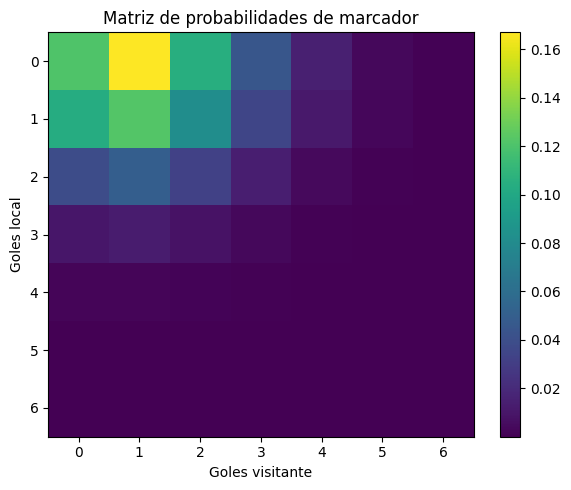

In [20]:
plt.figure(figsize=(6, 5))
plt.imshow(matrix, aspect="auto")
plt.colorbar()
plt.title("Matriz de probabilidades de marcador")
plt.xlabel("Goles visitante")
plt.ylabel("Goles local")
plt.tight_layout()
plt.show()

##  De la matriz de marcador a mercados más útiles

La matriz permite derivar probabilidades más fáciles de interpretar, como:

- victoria local,
- empate,
- victoria visitante,
- ambos marcan,
- over 2.5 goles.

In [21]:
def compute_fixture_probabilities(matrix: np.ndarray) -> Dict[str, float]:
    n = matrix.shape[0]
    home_win = float(sum(matrix[i, j] for i in range(n) for j in range(n) if i > j))
    draw = float(sum(matrix[i, i] for i in range(n)))
    away_win = float(sum(matrix[i, j] for i in range(n) for j in range(n) if i < j))
    return {
        "home_win": home_win,
        "draw": draw,
        "away_win": away_win,
    }


def top_scorelines(matrix: np.ndarray, top_n: int = 10) -> list[dict[str, float]]:
    rows = []
    n = matrix.shape[0]
    for i in range(n):
        for j in range(n):
            rows.append({"home_goals": i, "away_goals": j, "probability": float(matrix[i, j])})
    rows.sort(key=lambda x: x["probability"], reverse=True)
    return rows[:top_n]

In [22]:
fixture_probs = compute_fixture_probabilities(matrix)

print("Probabilidades del partido de ejemplo:")
display(pd.DataFrame([fixture_probs]))

print("Marcadores más probables:")
display(pd.DataFrame(top_scorelines(matrix, top_n=8)))

Probabilidades del partido de ejemplo:


,home_win,draw,away_win
0,0.231264,0.279789,0.488947


Marcadores más probables:


,home_goals,away_goals,probability
0,0,1,0.167011
1,1,1,0.122525
2,0,0,0.121340
3,0,2,0.104654
4,1,0,0.103279
5,1,2,0.081954
6,2,1,0.049788
7,0,3,0.044967


## Predicciones para un conjunto de partidos

Ahora generalizamos el proceso para muchos partidos.

Para cada encuentro vamos a guardar:

- goles reales,
- goles esperados,
- probabilidades 1X2,
- resultado observado.

In [23]:
def infer_outcome_from_goals(home_goals: int, away_goals: int) -> str:
    if home_goals > away_goals:
        return "home"
    if home_goals < away_goals:
        return "away"
    return "draw"


def probabilities_for_matches(model: DixonColesEloModel, matches: pd.DataFrame, max_goals: int) -> pd.DataFrame:
    rows = []
    for row in matches.itertuples(index=False):
        matrix, lam, mu = model.score_matrix(
            home_team_id=str(row.home_team_id),
            away_team_id=str(row.away_team_id),
            elo_diff=float(row.elo_diff),
            max_goals=max_goals,
        )
        probs = compute_fixture_probabilities(matrix)
        actual_outcome = infer_outcome_from_goals(int(row.home_goals), int(row.away_goals))

        rows.append({
            "event_id": row.event_id,
            "start_time": row.start_time,
            "home_team_id": row.home_team_id,
            "away_team_id": row.away_team_id,
            "home_goals": int(row.home_goals),
            "away_goals": int(row.away_goals),
            "elo_diff": float(row.elo_diff),
            "home_expected_goals": float(lam),
            "away_expected_goals": float(mu),
            "prob_home": float(probs["home_win"]),
            "prob_draw": float(probs["draw"]),
            "prob_away": float(probs["away_win"]),
            "actual_outcome": actual_outcome,
        })
    return pd.DataFrame(rows)

In [24]:
dev_pred = probabilities_for_matches(model, dev_df, max_goals=6)
dev_pred.head()

,event_id,start_time,home_team_id,away_team_id,home_goals,away_goals,elo_diff,home_expected_goals,away_expected_goals,prob_home,prob_draw,prob_away,actual_outcome
0,sr:sport_event:41892223,2023-08-11 17:30:00+00:00,sr:competitor:2858,sr:competitor:2818,0,2,0.0,1.226742,1.335993,0.345999,0.256662,0.397339,away
1,sr:sport_event:41892235,2023-08-11 20:00:00+00:00,sr:competitor:2833,sr:competitor:2828,1,2,0.0,1.331968,1.148698,0.413288,0.260726,0.325986,away
2,sr:sport_event:41892337,2023-08-12 15:00:00+00:00,sr:competitor:2824,sr:competitor:24264,1,1,0.0,1.377271,1.145653,0.426011,0.257390,0.316599,draw
3,sr:sport_event:41892237,2023-08-12 17:30:00+00:00,sr:competitor:6577,sr:competitor:2826,1,1,0.0,0.953524,0.889472,0.360233,0.314191,0.325576,draw
4,sr:sport_event:41892225,2023-08-12 19:30:00+00:00,sr:competitor:2825,sr:competitor:2829,0,2,0.0,1.140704,1.151394,0.360008,0.274704,0.365288,away


## Métricas probabilísticas

Cuando el objetivo final es predecir:

- local,
- empate,
- visitante,

no basta con mirar MAE de goles.  
Necesitamos métricas para probabilidades.

### Métricas que usaremos

- **Log loss**: castiga mucho cuando el modelo da muy poca probabilidad al resultado que realmente ocurrió.
- **Brier score**: error cuadrático de las probabilidades.
- **Accuracy**: porcentaje de veces que la clase más probable coincidió con el resultado real.
- **RPS**: versión ordenada para tres categorías.

In [25]:
def outcome_metrics_from_probability_frame(df: pd.DataFrame, prefix: str = "prob_") -> Dict[str, float]:
    if df.empty:
        return {
            "avg_log_loss": float("nan"),
            "avg_brier": float("nan"),
            "accuracy": float("nan"),
            "avg_rps": float("nan"),
        }

    log_losses = []
    briers = []
    accuracies = []
    rps_values = []

    for row in df.itertuples(index=False):
        probs = {
            "home": float(getattr(row, f"{prefix}home")),
            "draw": float(getattr(row, f"{prefix}draw")),
            "away": float(getattr(row, f"{prefix}away")),
        }
        actual = str(row.actual_outcome)

        log_losses.append(safe_log_loss(probs[actual]))
        briers.append(multiclass_brier(probs["home"], probs["draw"], probs["away"], actual))
        accuracies.append(float(predicted_outcome(probs["home"], probs["draw"], probs["away"]) == actual))
        rps_values.append(ranked_probability_score(probs["home"], probs["draw"], probs["away"], actual))

    return {
        "avg_log_loss": float(np.mean(log_losses)),
        "avg_brier": float(np.mean(briers)),
        "accuracy": float(np.mean(accuracies)),
        "avg_rps": float(np.mean(rps_values)),
    }

In [26]:
dev_prob_metrics = outcome_metrics_from_probability_frame(dev_pred, prefix="prob_")
pd.DataFrame([dev_prob_metrics])

,avg_log_loss,avg_brier,accuracy,avg_rps
0,0.949052,0.187255,0.547097,0.185407


## Tuning temporal de hiperparámetros

Además de los parámetros internos del optimizador, este pipeline puede ajustar:

- `xi` -> velocidad de decaimiento temporal,
- `elo_scale` -> escala de impacto del Elo,
- `reg_lambda` -> fuerza de regularización.

La selección se hace con **validación cruzada temporal** y usando como métrica principal el **log loss 1X2**.

Eso tiene sentido porque, en esta arquitectura, el producto final más importante son las probabilidades de resultado.

In [27]:
@dataclass
class TuningResult:
    xi: float
    elo_scale: float
    reg_lambda: float
    cv_avg_log_loss: float
    cv_avg_brier: float
    cv_avg_rps: float
    converged: bool


def time_series_cv_splits(dev_df: pd.DataFrame, n_splits: int) -> list[tuple[np.ndarray, np.ndarray]]:
    if len(dev_df) < n_splits + 2:
        raise ValueError(f"No hay suficientes partidos ({len(dev_df)}) para {n_splits} splits temporales.")
    splitter = TimeSeriesSplit(n_splits=n_splits)
    return list(splitter.split(dev_df))


def generate_oof_predictions(
    dev_df: pd.DataFrame,
    best_hparams: TuningResult,
    n_restarts: int,
    random_state: int,
    n_splits: int,
    max_goals: int,
) -> pd.DataFrame:
    splits = time_series_cv_splits(dev_df, n_splits=n_splits)
    oof_frames = []

    for fold_idx, (train_idx, val_idx) in enumerate(splits, start=1):
        fold_train = dev_df.iloc[train_idx].copy()
        fold_val = dev_df.iloc[val_idx].copy()

        model = DixonColesEloModel(
            xi=best_hparams.xi,
            elo_scale=best_hparams.elo_scale,
            reg_lambda=best_hparams.reg_lambda,
            max_goals=max_goals,
            n_restarts=n_restarts,
            random_state=random_state + 1000 + fold_idx,
        )
        model.fit(fold_train)

        fold_pred = probabilities_for_matches(model, fold_val, max_goals=max_goals)
        fold_pred["fold"] = fold_idx
        oof_frames.append(fold_pred)

    return pd.concat(oof_frames, ignore_index=True).sort_values(["start_time", "event_id"]).reset_index(drop=True)

In [28]:
def tune_dixon_coles(
    dev_df: pd.DataFrame,
    xi_grid: Sequence[float],
    elo_scale_grid: Sequence[float],
    reg_grid: Sequence[float],
    n_restarts: int,
    random_state: int,
    n_splits: int,
    max_goals: int,
) -> tuple[TuningResult, pd.DataFrame]:
    splits = time_series_cv_splits(dev_df, n_splits=n_splits)
    best_result = None
    cv_rows = []

    for xi in xi_grid:
        for elo_scale in elo_scale_grid:
            for reg_lambda in reg_grid:
                fold_metrics = []
                converged_flags = []

                for fold_idx, (train_idx, val_idx) in enumerate(splits, start=1):
                    fold_train = dev_df.iloc[train_idx].copy()
                    fold_val = dev_df.iloc[val_idx].copy()

                    model = DixonColesEloModel(
                        xi=float(xi),
                        elo_scale=float(elo_scale),
                        reg_lambda=float(reg_lambda),
                        max_goals=max_goals,
                        n_restarts=n_restarts,
                        random_state=random_state + fold_idx,
                    )
                    model.fit(fold_train)

                    fold_pred = probabilities_for_matches(model, fold_val, max_goals=max_goals)
                    metrics = outcome_metrics_from_probability_frame(fold_pred, prefix="prob_")

                    fold_metrics.append(metrics)
                    converged_flags.append(bool(model.optim_result_.success) if model.optim_result_ is not None else False)

                avg_log_loss = float(np.mean([m["avg_log_loss"] for m in fold_metrics]))
                avg_brier = float(np.mean([m["avg_brier"] for m in fold_metrics]))
                avg_rps = float(np.mean([m["avg_rps"] for m in fold_metrics]))

                result = TuningResult(
                    xi=float(xi),
                    elo_scale=float(elo_scale),
                    reg_lambda=float(reg_lambda),
                    cv_avg_log_loss=avg_log_loss,
                    cv_avg_brier=avg_brier,
                    cv_avg_rps=avg_rps,
                    converged=bool(all(converged_flags)),
                )

                cv_rows.append(asdict(result))

                if best_result is None or result.cv_avg_log_loss < best_result.cv_avg_log_loss:
                    best_result = result

    if best_result is None:
        raise RuntimeError("Falló el tuning.")

    return best_result, pd.DataFrame(cv_rows)

## Ejecutamos el proceso de tunning de hyperparameters

Esto funciona para encontrar los mejores parametros de nuestro modelo tras probar todas las combinaciones

In [29]:

 best_hparams_tuned, cv_results = tune_dixon_coles(
     dev_df=dev_df,
     xi_grid=[0.0015, 0.0030, 0.0050, 0.0075, 0.001],
     elo_scale_grid=[200.0, 300.0, 400.0, 600.0, 800.0],
     reg_grid=[0.005, 0.01, 0.02, 0.04, 0.06],
     n_restarts=3,
     random_state=42,
     n_splits=3,
     max_goals=6,
 )

 display(best_hparams_tuned)
 display(cv_results.sort_values("cv_avg_log_loss").head())

TuningResult(xi=0.003, elo_scale=800.0, reg_lambda=0.06, cv_avg_log_loss=1.0385629796505216, cv_avg_brier=0.20620798381082728, cv_avg_rps=0.2145079452651962, converged=True)

,xi,elo_scale,reg_lambda,cv_avg_log_loss,cv_avg_brier,cv_avg_rps,converged
49,0.003,800.0,0.06,1.038563,0.206208,0.214508,True
29,0.003,200.0,0.06,1.038602,0.206215,0.214517,True
34,0.003,300.0,0.06,1.038631,0.206221,0.214526,True
44,0.003,600.0,0.06,1.038653,0.206224,0.214531,True
39,0.003,400.0,0.06,1.038719,0.206235,0.214549,True


## Evaluación final sobre test

Una vez elegido el modelo y calibrada la temperatura con development, se evalúa sobre partidos futuros no usados en entrenamiento.

Ese es el momento en que realmente medimos:

- calidad de probabilidades,
- calidad de goles esperados,
- robustez fuera de muestra.

In [30]:
final_model = DixonColesEloModel(
    xi=best_hparams_tuned.xi,
    elo_scale=best_hparams_tuned.elo_scale,
    reg_lambda=best_hparams_tuned.reg_lambda,
    max_goals=6,
    n_restarts=3,
    random_state=42,
)

final_model.fit(dev_df)

test_pred = probabilities_for_matches(final_model, test_df, max_goals=6)

test_probs = test_pred[["prob_home", "prob_draw", "prob_away"]].to_numpy(dtype=float)

test_home_xg, test_away_xg = final_model.predict_expected_goals(test_df)

test_summary = {
    "raw_probability_metrics": outcome_metrics_from_probability_frame(test_pred, prefix="prob_"),
    "home_goal_metrics": evaluate_predictions(test_df["home_goals"], test_home_xg),
    "away_goal_metrics": evaluate_predictions(test_df["away_goals"], test_away_xg),
    "avg_goal_mae": average_goal_mae(test_df["home_goals"], test_home_xg, test_df["away_goals"], test_away_xg),
}

test_summary


df_summary = pd.json_normalize(test_summary)

df_summary.T

,0
avg_goal_mae,0.799312
raw_probability_metrics.avg_log_loss,0.963343
raw_probability_metrics.avg_brier,0.189733
raw_probability_metrics.accuracy,0.530928
raw_probability_metrics.avg_rps,0.195241
home_goal_metrics.mae,0.871013
home_goal_metrics.rmse,1.155029
home_goal_metrics.r2,0.096050
home_goal_metrics.mean_true,1.530928
home_goal_metrics.mean_pred,1.359806


## Además del modelo principal Dixon-Coles + Elo, se implementó un baseline más sencillo basado en regresión de Poisson, con el objetivo de comparar si la mayor complejidad del modelo principal aporta una mejora real en las métricas predictivas

In [31]:
from sklearn.linear_model import PoissonRegressor
import pandas as pd
import numpy as np

def build_poisson_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Creamos variables simples y fáciles de entender:
    - equipo local
    - equipo visitante
    - diferencia de elo
    """
    X = df[["home_team_id", "away_team_id", "elo_diff"]].copy()

    # Convertimos equipos en variables dummies (one-hot encoding)
    X = pd.get_dummies(
        X,
        columns=["home_team_id", "away_team_id"],
        drop_first=False
    )

    return X


# ------------------------------------------------------------
# 2) Preparamos train/test
# ------------------------------------------------------------
X_dev = build_poisson_features(dev_df)
X_test = build_poisson_features(test_df)

# Alineamos columnas para que train y test tengan exactamente las mismas
X_dev, X_test = X_dev.align(X_test, join="left", axis=1, fill_value=0)

y_dev_home = dev_df["home_goals"].astype(float)
y_dev_away = dev_df["away_goals"].astype(float)

y_test_home = test_df["home_goals"].astype(float)
y_test_away = test_df["away_goals"].astype(float)


# ------------------------------------------------------------
# 3) Entrenamos dos modelos Poisson:
#    uno para goles local, otro para goles visitante
# ------------------------------------------------------------
poisson_home = PoissonRegressor(alpha=0.1, max_iter=1000)
poisson_away = PoissonRegressor(alpha=0.1, max_iter=1000)

poisson_home.fit(X_dev, y_dev_home)
poisson_away.fit(X_dev, y_dev_away)


# ------------------------------------------------------------
# 4) Predicciones en TEST
# ------------------------------------------------------------
poisson_test_home_pred = poisson_home.predict(X_test)
poisson_test_away_pred = poisson_away.predict(X_test)


# ------------------------------------------------------------
# 5) Métricas del baseline Poisson en TEST
# ------------------------------------------------------------
poisson_test_home_metrics = evaluate_predictions(y_test_home, poisson_test_home_pred)
poisson_test_away_metrics = evaluate_predictions(y_test_away, poisson_test_away_pred)
poisson_test_avg_mae = average_goal_mae(
    y_test_home, poisson_test_home_pred,
    y_test_away, poisson_test_away_pred
)

print("=== Baseline Poisson Regression (TEST) ===")
print("Métricas goles local:")
display(pd.DataFrame([poisson_test_home_metrics]))

print("Métricas goles visitante:")
display(pd.DataFrame([poisson_test_away_metrics]))

print("MAE promedio total:", poisson_test_avg_mae)


# ------------------------------------------------------------
# 6) Predicciones del modelo Dixon-Coles en test
# ------------------------------------------------------------
dc_test_home_pred = test_home_xg
dc_test_away_pred = test_away_xg

dc_test_home_metrics = evaluate_predictions(y_test_home, dc_test_home_pred)
dc_test_away_metrics = evaluate_predictions(y_test_away, dc_test_away_pred)
dc_test_avg_mae = average_goal_mae(
    y_test_home, dc_test_home_pred,
    y_test_away, dc_test_away_pred
)


# ------------------------------------------------------------
# 7) Tabla comparativa final
# ------------------------------------------------------------
comparison_rows = [
    {
        "model": "Dixon-Coles + Elo",
        "target": "home_goals",
        **dc_test_home_metrics
    },
    {
        "model": "Dixon-Coles + Elo",
        "target": "away_goals",
        **dc_test_away_metrics
    },
    {
        "model": "Poisson Regression",
        "target": "home_goals",
        **poisson_test_home_metrics
    },
    {
        "model": "Poisson Regression",
        "target": "away_goals",
        **poisson_test_away_metrics
    },
]

comparison_df = pd.DataFrame(comparison_rows)

avg_mae_comparison = pd.DataFrame([
    {"model": "Dixon-Coles + Elo", "avg_goal_mae": dc_test_avg_mae},
    {"model": "Poisson Regression", "avg_goal_mae": poisson_test_avg_mae},
])

print("=== Comparación por target ===")
display(comparison_df)

print("=== Comparación MAE promedio total ===")
display(avg_mae_comparison)

=== Baseline Poisson Regression (TEST) ===
Métricas goles local:


,mae,rmse,r2,mean_true,mean_pred
0,0.875917,1.131045,0.133201,1.530928,1.443274


Métricas goles visitante:


,mae,rmse,r2,mean_true,mean_pred
0,0.752227,0.940937,0.128735,1.097938,1.158426


MAE promedio total: 0.8140718609499114
=== Comparación por target ===


,model,target,mae,rmse,r2,mean_true,mean_pred
0,Dixon-Coles + Elo,home_goals,0.871013,1.155029,0.096050,1.530928,1.359806
1,Dixon-Coles + Elo,away_goals,0.727611,0.915864,0.174550,1.097938,1.108292
2,Poisson Regression,home_goals,0.875917,1.131045,0.133201,1.530928,1.443274
3,Poisson Regression,away_goals,0.752227,0.940937,0.128735,1.097938,1.158426


=== Comparación MAE promedio total ===


,model,avg_goal_mae
0,Dixon-Coles + Elo,0.799312
1,Poisson Regression,0.814072


In [32]:
test_pred[[
    "event_id", "home_team_id", "away_team_id",
    "home_goals", "away_goals",
    "home_expected_goals", "away_expected_goals",
    "prob_home", "prob_draw", "prob_away",
    "actual_outcome"
]]

,event_id,home_team_id,away_team_id,home_goals,away_goals,home_expected_goals,away_expected_goals,prob_home,prob_draw,prob_away,actual_outcome
0,sr:sport_event:61623972,sr:competitor:2824,sr:competitor:2814,2,2,1.056612,0.940616,0.381099,0.298504,0.320397,draw
1,sr:sport_event:61623976,sr:competitor:2819,sr:competitor:24264,5,0,2.587018,1.289920,0.650212,0.172031,0.177756,home
2,sr:sport_event:61623964,sr:competitor:2851,sr:competitor:2829,0,3,0.115692,1.666964,0.023836,0.200255,0.775909,away
3,sr:sport_event:61623958,sr:competitor:2825,sr:competitor:2818,1,0,1.423911,0.589035,0.578752,0.263662,0.157585,home
4,sr:sport_event:61623974,sr:competitor:2833,sr:competitor:2859,1,2,1.148352,1.008356,0.393261,0.284393,0.322346,away
...,...,...,...,...,...,...,...,...,...,...,...
189,sr:sport_event:61624340,sr:competitor:2836,sr:competitor:2826,3,0,1.745542,0.569777,0.662747,0.217713,0.119540,home
190,sr:sport_event:61624342,sr:competitor:2817,sr:competitor:2851,3,0,2.571986,0.107824,0.901192,0.089052,0.009756,home
191,sr:sport_event:61624346,sr:competitor:2824,sr:competitor:2821,3,1,1.284019,1.204392,0.388184,0.261555,0.350260,home
192,sr:sport_event:61624338,sr:competitor:2885,sr:competitor:2816,2,1,1.010539,1.155889,0.321489,0.283542,0.394969,home


## Predicción de un partido futuro

El flujo de predicción de un partido nuevo es:

1. buscar el Elo actual de cada equipo,
2. calcular `elo_diff`,
3. usar el modelo para obtener \(\lambda\) y \(\mu\),
4. construir la matriz de marcadores,

In [33]:
def predict_fixture(model: DixonColesEloModel, current_ratings: Dict[str, float], home_team_id: str, away_team_id: str, max_goals: int = 6):
    home_rating = float(current_ratings.get(home_team_id, 1500.0))
    away_rating = float(current_ratings.get(away_team_id, 1500.0))
    elo_diff = home_rating - away_rating

    matrix, lam, mu = model.score_matrix(
        home_team_id=home_team_id,
        away_team_id=away_team_id,
        elo_diff=elo_diff,
        max_goals=max_goals,
    )

    probs = compute_fixture_probabilities(matrix)

    return {
        "home_team_id": home_team_id,
        "away_team_id": away_team_id,
        "elo_diff": elo_diff,
        "home_expected_goals": lam,
        "away_expected_goals": mu,
        "probabilities": probs,
        "top_scorelines": top_scorelines(matrix, top_n=10),
    }

In [34]:
future_example = predict_fixture(
    model=final_model,
    current_ratings=final_ratings,
    home_team_id="sr:competitor:2818",
    away_team_id="sr:competitor:2833",
    max_goals=6,
)

future_example

{'home_team_id': 'sr:competitor:2818',
 'away_team_id': 'sr:competitor:2833',
 'elo_diff': 29.123155261198463,
 'home_expected_goals': 1.3070304783282505,
 'away_expected_goals': 0.9725179185677563,
 'probabilities': {'home_win': 0.44691083822409483,
  'draw': 0.2709470264715668,
  'away_win': 0.2821421353043385},
 'top_scorelines': [{'home_goals': 1,
   'away_goals': 0,
   'probability': 0.13844080368310616},
  {'home_goals': 1, 'away_goals': 1, 'probability': 0.12550988533987947},
  {'home_goals': 0, 'away_goals': 1, 'probability': 0.1041933287338687},
  {'home_goals': 0, 'away_goals': 0, 'probability': 0.09775352208524163},
  {'home_goals': 2, 'away_goals': 0, 'probability': 0.08744954661280907},
  {'home_goals': 2, 'away_goals': 1, 'probability': 0.08504625105158307},
  {'home_goals': 1, 'away_goals': 2, 'probability': 0.06328008751598882},
  {'home_goals': 0, 'away_goals': 2, 'probability': 0.04841515830367386},
  {'home_goals': 2, 'away_goals': 2, 'probability': 0.041354501527338

## Modelos VS Benchmark

In [35]:
import pandas as pd
import numpy as np
from scipy.stats import poisson
from sklearn.metrics import accuracy_score, log_loss, brier_score_loss

# ============================================================
# 1. Cargar odds dataset
# ============================================================
odds_df = pd.read_csv("./dataset/laliga_lines_with_score.csv")

# Nos quedamos con una línea por partido (ej: promedio de books)
odds_agg = odds_df.groupby("SportRadarId").agg({
    "home_line": "mean",
    "away_line": "mean",
    "draw_line": "mean",
    "home_score": "first",
    "away_score": "first",
    "winner": "first"
}).reset_index()


In [36]:
odds_agg.head(10)

def scores_to_winner(home_goals, away_goals):
    if home_goals > away_goals:
        return "home"
    elif home_goals < away_goals:
        return "away"
    else:
        return "draw"

if "winner" not in test_df.columns:
    test_df = test_df.copy()
    test_df["winner"] = test_df.apply(
        lambda row: scores_to_winner(row["home_goals"], row["away_goals"]),
        axis=1
    )

print(test_df[["home_goals", "away_goals", "winner"]].head())

     home_goals  away_goals winner
775           2           2   draw
776           5           0   home
777           0           3   away
778           1           0   home
779           1           2   away


## Antes de esto vamos a re-entrenar nuestro modelo Dixon-coles con todo el dataset, ya que usaremos partidos del futuro (datos de partidos despues de la fecha que cubre nustro dataset) para medir rendimiento

In [37]:
final_model = DixonColesEloModel(
    xi=best_hparams_tuned.xi,
    elo_scale=best_hparams_tuned.elo_scale,
    reg_lambda=best_hparams_tuned.reg_lambda,
    max_goals=6,
    n_restarts=3,
    random_state=42,
)

final_model.fit(matches)


X_dev = build_poisson_features(matches)
y_dev_home = matches["home_goals"].astype(float)
y_dev_away = matches["away_goals"].astype(float)


poisson_home = PoissonRegressor(alpha=0.1, max_iter=1000)
poisson_away = PoissonRegressor(alpha=0.1, max_iter=1000)

poisson_home.fit(X_dev, y_dev_home)
poisson_away.fit(X_dev, y_dev_away)


,"alpha alpha: float, default=1Constant that multiplies the L2 penalty term and determines theregularization strength. ``alpha = 0`` is equivalent to unpenalizedGLMs. In this case, the design matrix `X` must have full column rank(no collinearities).Values of `alpha` must be in the range `[0.0, inf)`.",0.1
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the linear predictor (`X @ coef + intercept`).",True
,"solver solver: {'lbfgs', 'newton-cholesky'}, default='lbfgs'Algorithm to use in the optimization problem:'lbfgs' Calls scipy's L-BFGS-B optimizer.'newton-cholesky' Uses Newton-Raphson steps (in arbitrary precision arithmetic equivalent to iterated reweighted least squares) with an inner Cholesky based solver. This solver is a good choice for `n_samples` >> `n_features`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features` because it explicitly computes the Hessian matrix. .. versionadded:: 1.2",'lbfgs'
,"max_iter max_iter: int, default=100The maximal number of iterations for the solver.Values must be in the range `[1, inf)`.",1000
,"tol tol: float, default=1e-4Stopping criterion. For the lbfgs solver,the iteration will stop when ``max{|g_j|, j = 1, ..., d} <= tol``where ``g_j`` is the j-th component of the gradient (derivative) ofthe objective function.Values must be in the range `(0.0, inf)`.",0.0001
,"warm_start warm_start: bool, default=FalseIf set to ``True``, reuse the solution of the previous call to ``fit``as initialization for ``coef_`` and ``intercept_`` .",False
,"verbose verbose: int, default=0For the lbfgs solver set verbose to any positive number for verbosity.Values must be in the range `[0, inf)`.",0


## Guardamos nuestros modelos por si queremos usarlos posteriormente

In [38]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [39]:
import joblib

# si final_ratings es DataFrame → convertir a dict
if isinstance(final_ratings, pd.DataFrame):
    final_ratings_dict = dict(zip(final_ratings["team_id"], final_ratings["final_elo"]))
else:
    final_ratings_dict = final_ratings

joblib.dump({
    "model": final_model,
    "ratings": final_ratings_dict
}, "models/dixon_coles_model.pkl")

joblib.dump({
    "home_model": poisson_home,
    "away_model": poisson_away,
    "columns": X_dev.columns.tolist()
}, "models/poisson_model.pkl")

['models/poisson_model.pkl']

In [40]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, log_loss

# ============================================================
# 1. Helpers
# ============================================================
def american_to_prob(odds):
    odds = float(odds)
    if odds > 0:
        return 100.0 / (odds + 100.0)
    return (-odds) / ((-odds) + 100.0)

def scores_to_winner(home_goals, away_goals):
    if home_goals > away_goals:
        return "home"
    elif home_goals < away_goals:
        return "away"
    return "draw"

def winner_to_onehot(w):
    if w == "home":
        return [1, 0, 0]
    elif w == "draw":
        return [0, 1, 0]
    elif w == "away":
        return [0, 0, 1]
    raise ValueError(f"Winner desconocido: {w}")

def evaluate_probs(df_probs):
    y_true_labels = df_probs["winner"].values
    y_true_idx = np.array([{"home": 0, "draw": 1, "away": 2}[x] for x in y_true_labels])

    y_pred = df_probs[["p_home", "p_draw", "p_away"]].values
    pred_idx = y_pred.argmax(axis=1)

    acc = accuracy_score(y_true_idx, pred_idx)
    ll = log_loss(np.array([winner_to_onehot(w) for w in y_true_labels]), y_pred)
    brier = np.mean(np.sum((y_pred - np.array([winner_to_onehot(w) for w in y_true_labels])) ** 2, axis=1))

    return {
        "matches": len(df_probs),
        "accuracy": acc,
        "log_loss": ll,
        "brier_score": brier,
    }

# ============================================================
# 2. Cargar dataset y filtrar fecha
# ============================================================
odds_df = pd.read_csv("./dataset/laliga_lines_with_score.csv")
odds_df["Date"] = pd.to_datetime(odds_df["Date"])

eval_df = odds_df[odds_df["Date"] > "2026-01-27"].copy()

# una fila por partido real
matches_df = (
    eval_df.groupby("SportRadarId", as_index=False)
    .agg({
        "Date": "first",
        "Description": "first",
        "home_team_id": "first",
        "away_team_id": "first",
        "home_score": "first",
        "away_score": "first"
    })
)

matches_df["winner"] = matches_df.apply(
    lambda row: scores_to_winner(row["home_score"], row["away_score"]),
    axis=1
)

print("Partidos de evaluación:", len(matches_df))
display(matches_df.head())

# ============================================================
# 3. modelo Dixon-Coles + Elo usando predict_fixture
# ============================================================
dc_probs = []

for _, row in matches_df.iterrows():
    pred = predict_fixture(
        model=final_model,
        current_ratings=final_ratings,
        home_team_id=row["home_team_id"],
        away_team_id=row["away_team_id"],
        max_goals=6,
    )

    probs = pred["probabilities"]

    dc_probs.append({
        "SportRadarId": row["SportRadarId"],
        "winner": row["winner"],
        "p_home": probs["home_win"],
        "p_draw": probs["draw"],
        "p_away": probs["away_win"],
        "home_xg": pred["home_expected_goals"],
        "away_xg": pred["away_expected_goals"],
    })

dc_probs_df = pd.DataFrame(dc_probs)

# ============================================================
# 4. Baseline Poisson
# ============================================================
X_eval = matches_df[["home_team_id", "away_team_id"]].copy()
X_eval = pd.get_dummies(
    X_eval,
    columns=["home_team_id", "away_team_id"],
    drop_first=False
)

# alinear con las columnas del entrenamiento Poisson
X_eval = X_eval.reindex(columns=X_dev.columns, fill_value=0)

poisson_home_pred = poisson_home.predict(X_eval)
poisson_away_pred = poisson_away.predict(X_eval)

# convertir xG del Poisson a probs 1X2
from scipy.stats import poisson as scipy_poisson

def xg_to_match_probs(home_xg, away_xg, max_goals=10):
    probs = np.zeros(3)

    for i in range(max_goals + 1):
        p_i = scipy_poisson.pmf(i, home_xg)
        for j in range(max_goals + 1):
            p = p_i * scipy_poisson.pmf(j, away_xg)
            if i > j:
                probs[0] += p
            elif i == j:
                probs[1] += p
            else:
                probs[2] += p

    probs = probs / probs.sum()
    return probs

poisson_probs = []
for idx, row in matches_df.iterrows():
    p_home, p_draw, p_away = xg_to_match_probs(
        poisson_home_pred[idx],
        poisson_away_pred[idx]
    )

    poisson_probs.append({
        "SportRadarId": row["SportRadarId"],
        "winner": row["winner"],
        "p_home": p_home,
        "p_draw": p_draw,
        "p_away": p_away,
        "home_xg": poisson_home_pred[idx],
        "away_xg": poisson_away_pred[idx],
    })

poisson_probs_df = pd.DataFrame(poisson_probs)

# ============================================================
# 5. Sportsbooks individuales
# ============================================================
book_results = []

for book_name, book_df in eval_df.groupby("SportsbookName"):
    tmp = book_df.copy()

    tmp["p_home_raw"] = tmp["home_line"].apply(american_to_prob)
    tmp["p_draw_raw"] = tmp["draw_line"].apply(american_to_prob)
    tmp["p_away_raw"] = tmp["away_line"].apply(american_to_prob)

    total = tmp["p_home_raw"] + tmp["p_draw_raw"] + tmp["p_away_raw"]
    tmp["p_home"] = tmp["p_home_raw"] / total
    tmp["p_draw"] = tmp["p_draw_raw"] / total
    tmp["p_away"] = tmp["p_away_raw"] / total

    merged = matches_df[["SportRadarId", "winner"]].merge(
        tmp[["SportRadarId", "p_home", "p_draw", "p_away"]],
        on="SportRadarId",
        how="inner"
    )

    if len(merged) == 0:
        continue

    metrics = evaluate_probs(merged)
    metrics["model"] = book_name
    metrics["type"] = "sportsbook"
    book_results.append(metrics)

sportsbooks_results_df = pd.DataFrame(book_results)

# ============================================================
# 6. Evaluar los modelos
# ============================================================
dc_metrics = evaluate_probs(dc_probs_df)
dc_metrics["model"] = "Dixon-Coles + Elo"
dc_metrics["type"] = "model"

poisson_metrics = evaluate_probs(poisson_probs_df)
poisson_metrics["model"] = "Poisson Regression"
poisson_metrics["type"] = "model"

# ============================================================
# 7. Resultado final
# ============================================================
final_results_df = pd.concat(
    [
        pd.DataFrame([dc_metrics, poisson_metrics]),
        sportsbooks_results_df
    ],
    ignore_index=True
)

final_results_df = final_results_df.sort_values(
    by=["accuracy", "log_loss", "brier_score"],
    ascending=[False, True, True]
).reset_index(drop=True)

print("=== Comparación final: modelos vs sportsbooks ===")
display(final_results_df)

# ============================================================
# 8. Resumen contra promedio de books
# ============================================================
if len(sportsbooks_results_df) > 0:
    avg_books = {
        "model": "AVG Sportsbooks",
        "type": "benchmark",
        "matches": sportsbooks_results_df["matches"].mean(),
        "accuracy": sportsbooks_results_df["accuracy"].mean(),
        "log_loss": sportsbooks_results_df["log_loss"].mean(),
        "brier_score": sportsbooks_results_df["brier_score"].mean(),
    }

    summary_df = pd.DataFrame([
        dc_metrics,
        poisson_metrics,
        avg_books
    ])

    print("===  modelos vs promedio de sportsbooks ===")
    display(summary_df)

Partidos de evaluación: 81


,SportRadarId,Date,Description,home_team_id,away_team_id,home_score,away_score,winner
0,sr:sport_event:61624358,2026-02-01 20:00:00,Real Sociedad San Sebastian@Athletic Bilbao,sr:competitor:2825,sr:competitor:2824,1,1,draw
1,sr:sport_event:61624360,2026-02-01 15:15:00,Valencia CF@Real Betis Seville,sr:competitor:2816,sr:competitor:2828,2,1,home
2,sr:sport_event:61624362,2026-02-02 20:00:00,Sevilla FC@RCD Mallorca,sr:competitor:2826,sr:competitor:2833,4,1,home
3,sr:sport_event:61624364,2026-01-31 15:15:00,Villarreal CF@CA Osasuna,sr:competitor:2820,sr:competitor:2819,2,2,draw
4,sr:sport_event:61624366,2026-01-30 20:00:00,Deportivo Alaves@Espanyol Barcelona,sr:competitor:2814,sr:competitor:2885,1,2,away


=== Comparación final: modelos vs sportsbooks ===


,matches,accuracy,log_loss,brier_score,model,type
0,80,0.562500,0.964353,0.568468,Bet105,sportsbook
1,81,0.543210,0.967103,0.570642,BetOnLine,sportsbook
2,81,0.543210,0.967103,0.570642,SportsBetting,sportsbook
3,81,0.543210,0.968002,0.571325,Bodog,sportsbook
4,80,0.537500,0.959994,0.566850,JustBet,sportsbook
5,80,0.537500,0.960084,0.566713,BookMaker,sportsbook
6,81,0.530864,0.969942,0.572328,Intertops,sportsbook
7,81,0.530864,0.971664,0.573474,BetAnySports,sportsbook
8,81,0.530864,0.974010,0.575605,MyBookie,sportsbook
9,81,0.506173,0.987841,0.584569,Dixon-Coles + Elo,model


===  modelos vs promedio de sportsbooks ===


,matches,accuracy,log_loss,brier_score,model,type
0,81.0,0.506173,0.987841,0.584569,Dixon-Coles + Elo,model
1,81.0,0.493827,1.032888,0.619638,Poisson Regression,model
2,73.6,0.535972,0.968895,0.572412,AVG Sportsbooks,benchmark


In [41]:
from sklearn.metrics import mean_absolute_error

# ============================================================
# 1. MÉTRICAS DE GOLES (MISMO DATASET)
# ============================================================

# Dixon-Coles
dc_home_mae = mean_absolute_error(
    matches_df["home_score"],
    dc_probs_df["home_xg"]
)

dc_away_mae = mean_absolute_error(
    matches_df["away_score"],
    dc_probs_df["away_xg"]
)

dc_goal_mae = (dc_home_mae + dc_away_mae) / 2


# Poisson
poisson_home_mae = mean_absolute_error(
    matches_df["home_score"],
    poisson_probs_df["home_xg"]
)

poisson_away_mae = mean_absolute_error(
    matches_df["away_score"],
    poisson_probs_df["away_xg"]
)

poisson_goal_mae = (poisson_home_mae + poisson_away_mae) / 2


# ============================================================
# 2. MÉTRICAS DE RESULTADO (YA LAS TENEMOS)
# ============================================================

dc_eval = evaluate_probs(dc_probs_df)
poisson_eval = evaluate_probs(poisson_probs_df)


# ============================================================
# 3. COMPARACIÓN FINAL CLARA
# ============================================================

diagnostic_df = pd.DataFrame([
    {
        "model": "Dixon-Coles + Elo",
        "goal_mae": dc_goal_mae,
        "home_mae": dc_home_mae,
        "away_mae": dc_away_mae,
        "log_loss": dc_eval["log_loss"],
        "accuracy": dc_eval["accuracy"],
    },
    {
        "model": "Poisson Regression",
        "goal_mae": poisson_goal_mae,
        "home_mae": poisson_home_mae,
        "away_mae": poisson_away_mae,
        "log_loss": poisson_eval["log_loss"],
        "accuracy": poisson_eval["accuracy"],
    }
])

print("=== DIAGNÓSTICO: GOLES vs RESULTADO ===")
display(diagnostic_df)

=== DIAGNÓSTICO: GOLES vs RESULTADO ===


,model,goal_mae,home_mae,away_mae,log_loss,accuracy
0,Dixon-Coles + Elo,0.825406,0.942855,0.707958,0.987841,0.506173
1,Poisson Regression,0.837217,1.038007,0.636427,1.032888,0.493827
